<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/Pytorch_Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Exercise 1.

In [2]:
import torch
import numpy as np

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
N=100;
x_lin = np.linspace(-np.pi,np.pi,N)

In [9]:
class SimpleNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size1)
        self.tanh = torch.nn.Tanh()
        self.fc2 = torch.nn.Linear(hidden_size1, hidden_size2)
        # self.tanh = torch.nn.Tanh()
        self.fc3 = torch.nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.tanh(out)
        out = self.fc2(out)
        out = self.tanh(out)
        out = self.fc3(out)
        return out

In [10]:
input_size = 1
hidden_size1 = 50
hidden_size2 = 50
output_size = 1

model = SimpleNN(input_size, hidden_size1, hidden_size2, output_size).to(device)

# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

epochs = 10000

for epoch in range(epochs):
    model.train() # Set the model to training mode
    x = torch.tensor(x_lin, dtype=torch.float32).to(device).unsqueeze(1) # Add a dimension for batch size
    y = torch.sin(x) # Target output

    # Forward pass
    y_pred = model(x)
    loss = criterion(y_pred, y)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [1000/10000], Loss: 0.0001
Epoch [2000/10000], Loss: 0.0000
Epoch [3000/10000], Loss: 0.0000
Epoch [4000/10000], Loss: 0.0000
Epoch [5000/10000], Loss: 0.0000
Epoch [6000/10000], Loss: 0.0000
Epoch [7000/10000], Loss: 0.0001
Epoch [8000/10000], Loss: 0.0000
Epoch [9000/10000], Loss: 0.0000
Epoch [10000/10000], Loss: 0.0000


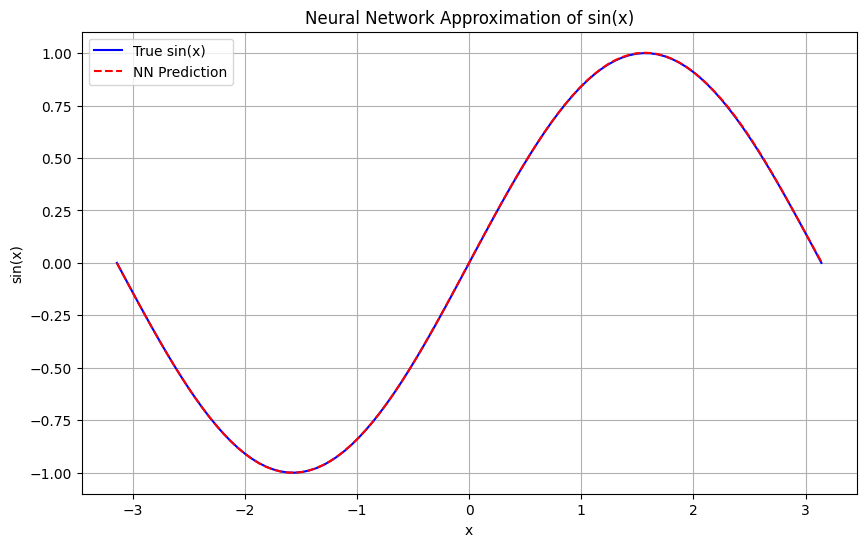

In [13]:
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

# Make predictions
with torch.no_grad():
    x_test = torch.tensor(x_lin, dtype=torch.float32).to(device).unsqueeze(1)
    y_pred_test = model(x_test)

# Move data to CPU for plotting
x_plot = x_lin
y_true_plot = np.sin(x_lin) # Original sine wave
y_pred_plot = y_pred_test.cpu().numpy().squeeze()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true_plot, label='True sin(x)', color='blue')
plt.plot(x_plot, y_pred_plot, label='NN Prediction', color='red', linestyle='--')
plt.title('Neural Network Approximation of sin(x)')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.legend()
plt.grid(True)
plt.show()